In [1]:
import os
import cv2
import json
import base64
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
import plotly.express as px
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image

from utils.model2_explain import ObjectStateNet
from utils.data import MyDataset
from torch.utils.data import DataLoader

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from PIL import Image
from IPython.display import display, clear_output

## 1. Function Utils

In [3]:
def load_model(backbone, attn, num_classes, checkpoint, device="cuda"):
    state_dict = torch.load(checkpoint, map_location=device)
    model = ObjectStateNet(
        backbone_name=backbone,
        num_classes=num_classes,
        pretrained=True,
        attn_type=attn,
        use_residual=True,
        fusion="object"
    )
    model.load_state_dict(state_dict)
    torch.set_grad_enabled(True) 
    model.to(device).eval()
    print(f"✅ Model loaded from {checkpoint}")
    return model

In [4]:
def get_data(ann_file, label2id, img_path_root):
    data = []
    with open(ann_file, "r") as fp:
        raw_data = json.loads(fp.read())
    
    for k, v in raw_data.items():
        img_name = f"{k}.jpg"
        img_path = os.path.join(img_path_root, img_name)
    
        for i, ann in v.items():
            x1,y1,x2,y2 = ann["bbox"] #xyxy
            w = x2 - x1
            h = y2 - y1
            label = ann["label"]
            if label == "Unrelated Region":
                continue
    
            data.append({
                "img_path": img_path,
                "bbox": [x1, y1, w, h],
                "label": label2id[label]
            })
            
    return data

In [5]:
def img_preprocess(item):
    img_path = item["img_path"]
    bbox = item["bbox"]
    label = item["label"]
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    original_img = Image.open(img_path).convert("RGB")
    img_W, img_H = original_img.size
    x1, y1, w, h = bbox
    x2 = x1 + w
    y2 = y1 + h
    cropped_region = original_img.crop((x1, y1, x2, y2))

    image = test_transform(original_img)
    cropped_region = test_transform(cropped_region)

    bbox_normed = torch.tensor([
        x1 / img_W,
        y1 / img_H,
        x2 / img_W,
        y2 / img_H
    ], dtype=torch.float32)

    return {
        "original": image.unsqueeze(0).cuda(),
        "crop": cropped_region.unsqueeze(0).cuda(),
        "bbox": bbox_normed.unsqueeze(0).cuda(),
        "label": label
    }

In [6]:
def get_dataloader(ds_id, train_transform, test_transform, use_subset=False):
    datasets = [
        "1. gas cylinder",
        "2. working at height",
        "3. worker with hardhat & vest",
        "4. working with eye protection",
        "5. vehicle"
    ]

    dataset = datasets[ds_id]

    train_img_path = f"./config_file/{dataset}/trainImgs/"
    train_ann_file = f"./config_file/{dataset}/train.json"
    test_img_path = f"./config_file/{dataset}/testImgs/"
    test_ann_file = f"./config_file/{dataset}/testImgs/bboxes_{ds_id + 1}.json"
    labels_file = f"./config_file/{dataset}/testImgs/labels_{ds_id + 1}.json"
    with open(labels_file, "r") as fp:
        label2id = json.loads(fp.read())
    num_classes = len(label2id)
    id2label = {v: k for k, v in label2id.items()}



    train_dataset = MyDataset(
        img_path_root=train_img_path,
        ann_file=train_ann_file,
        label2id=label2id,
        dataType="train",
        transform=train_transform,
    )
    test_dataset = MyDataset(
        img_path_root=test_img_path,
        ann_file=test_ann_file,
        label2id=label2id,
        dataType="test",
        transform=test_transform
    )

    seed = 42

    # ✅ 如果启用子集
    if use_subset:
        subset_ratio = 0.7
        print(f"⚙️ 正在对子集进行采样 (subset_ratio={subset_ratio})...")
        train_dataset = create_balanced_subset(train_dataset, subset_ratio=subset_ratio, seed=seed)
        # test_dataset = create_balanced_subset(test_dataset, subset_ratio=subset_ratio, seed=seed)


    g = torch.Generator()
    g.manual_seed(seed)

    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
    test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    return train_dataloader, test_dataloader, num_classes, id2label

In [7]:
# 获取特征数据

class _SaveInputHook:
    def __init__(self): self.buf = []
    def __call__(self, module, inputs, output):
        x = inputs[0].detach()   # [B, D]
        self.buf.append(x)

@torch.no_grad()
def collect_feats_labels_images(model, dataloader, device):
    """
    返回：
      feats: [N,D] 进入 classifier 的融合特征（你现在论文里的“语义表示”）
      labels: [N]
      imgs_crop:  [N,3,224,224] （只用来可视化原型/检索，不需要文件路径）
      imgs_global:[N,3,224,224]
    """
    model.eval().to(device)
    hooker = _SaveInputHook()
    h = model.classifier.register_forward_hook(hooker)

    all_preds, all_labels, crops, glbs, bboxes, paths = [], [], [], [], [], []
    for batch in dataloader:
        img_glb = batch["original"].to(device)
        img_obj = batch["crop"].to(device)
        bbox    = batch["bbox"].to(device)
        img_path = batch["img_path"]

        preds = model(img_global=img_glb, img_object=img_obj, bbox=bbox)
        # preds = preds.argmax(dim=1)
        
        all_labels.append(batch["label"].cpu())
        crops.append(batch["crop"].cpu())
        glbs.append(batch["original"].cpu())
        bboxes.extend(bbox.cpu().numpy().tolist())
        paths.extend(img_path)
        
    h.remove()
    feats  = torch.cat(hooker.buf, dim=0).cpu().numpy()
    labels = torch.cat(all_labels, dim=0).cpu().numpy().astype(int)
    imgs_crop   = torch.cat(crops, dim=0)     # [N,3,224,224]
    imgs_global = torch.cat(glbs,  dim=0)
    return feats, labels, imgs_crop, imgs_global, bboxes, paths

## 2. 准备工作【定义模型和数据】

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # transforms.RandomRotation(10),
    # transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # <======== 加了这个内容，效果有显著提升。=======
])

In [52]:
backbones = ["vit_b_16",  "convnext_large",]#

checkpoints = {
    "vit_b_16":[
        "./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_vit_b_16_bicross_model_bbtrainable.pth",
    ],
    "convnext_large":[
        "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_convnext_large_bicross_model_bbtrainable.pth",
    ]
}

perplexities = [10, 20, 30, 40, 50]
learning_rates = [200, 300, 500, 800, 1300]
metrics = ["cosine", "euclidean"] 


for backbone in backbones:
    for ds_id in range(0,5):
        checkpoint = checkpoints[backbone][ds_id]
        
        train_dataloader, test_dataloader, num_classes, ids2labels = get_dataloader(
            ds_id = ds_id,
            train_transform = train_transform,
            test_transform = test_transform,
            use_subset=False
        )
        
        model = load_model(
            backbone = backbone,
            attn = "bicross",
            num_classes = num_classes,
            checkpoint = checkpoint
        )
        model.eval();
        
        folder_path = f"./embedding distribution/{backbone}/{ds_id}/"
        
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
        print(f"---processing--> {backbone} - {ds_id}")

        feats, labels, imgs_crop, imgs_global, bboxes, paths = collect_feats_labels_images(
            model = model,
            dataloader=test_dataloader,
            device= "cuda" if torch.cuda.is_available() else "cpu"
        )

        for pp in perplexities:
            for lr in learning_rates:
                for m in metrics:
                    output_img_path = folder_path + f"Dataset_{pp}_{lr}_{m}.jpg"
                    plot_tsne_pca(
                        feats=feats, 
                        labels=labels, 
                        class_names=list(ids2labels.values()), 
                        method="tsne", 
                        perplexity=pp, 
                        learning_rate = lr,
                        metric = m, 
                        seed=0, 
                        save_path = output_img_path
                    )
    #     break
    # break

✅ Model loaded from ./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 0
✅ Model loaded from ./config_file/explanable_results/models/1_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 1
✅ Model loaded from ./config_file/explanable_results/models/2_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 2
✅ Model loaded from ./config_file/explanable_results/models/3_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 3
✅ Model loaded from ./config_file/explanable_results/models/4_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 4
✅ Model loaded from ./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth
---processing--> convnext_large - 0
✅ Model loaded from ./config_file/explanable_results/models/1_convnext_large_bicross_model_bbtrainable.pth
---processing--> convnext_large - 1
✅ Model loaded from ./config_file/explanable_results/models

## 3. 获取数据特征

In [55]:
# 1. 获取数据
ds_id = 4

train_dataloader, test_dataloader, num_classes, ids2labels = get_dataloader(
    ds_id = ds_id,
    train_transform = train_transform,
    test_transform = test_transform,
    use_subset=False
)

# 2. 获取checkpoint和模型
bb_id = 1
backbones = [ "vit_b_16", "convnext_large",] 

checkpoints = {
    "vit_b_16":[
        "./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_vit_b_16_bicross_model_bbtrainable.pth",
    ],
    "convnext_large":[
        "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_convnext_large_bicross_model_bbtrainable.pth",
    ]
}

checkpoint = checkpoints[backbones[bb_id]][ds_id]
model = load_model(
    backbone = backbones[bb_id],
    attn = "bicross",
    num_classes = num_classes,
    checkpoint = checkpoint
)
model.eval();

# 3. 获取最后的结果
feats, labels, imgs_crop, imgs_global, bboxes, paths = collect_feats_labels_images(
    model = model,
    dataloader=test_dataloader,
    device= "cuda" if torch.cuda.is_available() else "cpu"
)

output_img_path = "C:/Dropbox/Dropbox/2. myResearch/thesis/figures/Figure 5.22/" + f"{backbones[bb_id]}_{ds_id+1}.jpg"

pp = 20
lr = 300
m = "euclidean"

plot_tsne_pca(
    feats=feats, 
    labels=labels, 
    class_names=list(ids2labels.values()), 
    method="tsne", 
    perplexity=pp, 
    learning_rate = lr,
    metric = m, 
    seed=0, 
    save_path = output_img_path
)

✅ Model loaded from ./config_file/explanable_results/models/4_convnext_large_bicross_model_bbtrainable.pth


## 3.1 特征分布可视化

In [9]:
## 原始图片
def plot_tsne_pca(feats, labels, class_names=None, method="tsne", perplexity=30, learning_rate=100, metric="cosine", seed=0, save_path=None):
    # 归一化到单位长度（余弦更稳定）
    X = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-12)

    if method.lower()=="tsne":
        from sklearn.manifold import TSNE
        Y = TSNE(
            n_components=2, 
            max_iter=1000,
            init="pca", 
            early_exaggeration=12,
            learning_rate=learning_rate,
            perplexity=perplexity, 
            random_state=seed,
            metric=metric
        ).fit_transform(X)
        title = f"t-SNE (perplexity={perplexity})"
    else:
        # PCA 作为备选
        from sklearn.decomposition import PCA
        Y = PCA(n_components=2, random_state=seed).fit_transform(X)
        title = "PCA (first 2 PCs)"

    plt.figure(figsize=(6,5))
    K = labels.max()+1
    for c in range(K):
        idx = (labels==c)
        plt.scatter(Y[idx,0], Y[idx,1], s=12, alpha=0.7, label=class_names[c] if class_names else f"c{c}")
    # plt.legend(
    #     loc="center left",
    #     bbox_to_anchor=(1.02, 0.5),
    #     ncol=1,                 # 初始1列
    #     borderaxespad=0,
    #     fontsize=9
    # )
    # plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()
    plt.close()

In [10]:
import plotly.io as pio

# 如果是经典 Jupyter Notebook
pio.renderers.default = 'notebook' 

def plot_tsne_pca_plotly(
    feats, 
    labels, 
    class_names=None, 
    method="tsne", 
    perplexity=30, learning_rate=100, metric="cosine",
    seed=0,
    img_names=None,
    bboxes=None,
    save_path = None
):
    X = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-12)

    if method.lower() == "tsne":
        from sklearn.manifold import TSNE
        Y = TSNE(
            n_components=2, 
            max_iter=1000,
            init="pca", 
            early_exaggeration=12,
            learning_rate=learning_rate,
            perplexity=perplexity, 
            random_state=seed,
            metric=metric
        ).fit_transform(X)
        title = f"t-SNE (perplexity={perplexity})"
    else:
        from sklearn.decomposition import PCA
        Y = PCA(n_components=2, random_state=seed).fit_transform(X)
        title = "PCA (first 2 PCs)"

    
    df = pd.DataFrame({
        "x": Y[:,0],
        "y": Y[:,1],
        "label": labels
    })

    if class_names is not None:
        df["class_name"] = [class_names[l] for l in labels]
    else:
        df["class_name"] = labels.astype(str)

    if img_names is not None:
        df["img"] = img_names
    else:
        df["img"] = ""
    
    if bboxes is not None:
        bbox_list = []
        tag_list = []
        for i, (img_path, bbox) in enumerate(zip(img_names, bboxes)):
            img = Image.open(img_path)
            w, h = img.size
            x1, y1, x2, y2 = bbox
            bbox_list.append(str([int(x1*w), int(y1*h), int(x2*w), int(y2*h)]))
            tag_list.append(i)
            
        df["bbox"] = bbox_list
        df["tag"] = tag_list
    else:
        df["bbox"] = ""
        df["tag"] = ""

    fig = px.scatter(
        df,
        x="x",
        y="y",
        color="class_name",
        title=title,
        hover_data=["class_name", "bbox", "img", "tag"]
    )

    fig.update_traces(marker=dict(size=6, opacity=0.7))

    # ✅ 点击事件（关键）
    def show_image(trace, points, state):
        if len(points.point_inds) == 0:
            return
        idx = points.point_inds[0]

        path = df.iloc[idx]["img"]
        bbox = df.iloc[idx]["bbox"]

        print(f"\nImage: {path}")
        print(f"BBox: {bbox}")

        img = Image.open(path)
        plt.imshow(img)
        plt.title(f"{df.iloc[idx]['class_name']}")
        plt.axis("off")
        plt.show()

    fig.data[0].on_click(show_image)

    fig.show()

In [56]:
plot_tsne_pca_plotly(
    feats=feats, 
    labels=labels, 
    class_names=list(ids2labels.values()), 
    method="tsne", 
    perplexity=10, 
    learning_rate = 500,
    metric = "cosine", # euclidean，cosine
    seed=0, 
    img_names=paths,
    bboxes=bboxes,
    save_path = None
)

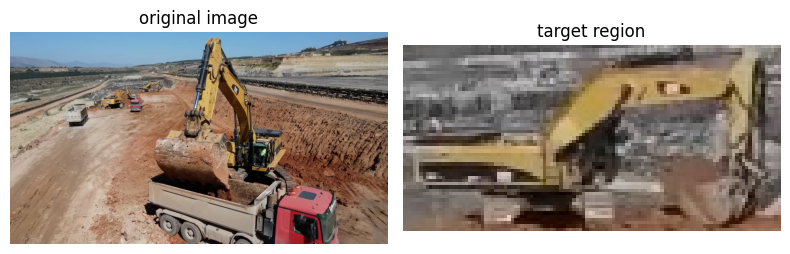

In [61]:
id_tag = 78
img_path = paths[id_tag]
x1, y1, x2, y2 = bboxes[id_tag]
image = Image.open(img_path).convert("RGB")
w, h = image.size
target = image.crop((int(x1*w), int(y1*h), int(x2*w), int(y2*h)))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("original image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(target)
plt.title("target region")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3.2 样本-类中心（原型）相似度条形图

\* 注：这个样本-类中心的作用，就是用来解释，**样本**为何被判成**某个类**。

In [24]:
@torch.no_grad()
def plot_sample_to_centers(model, feat_vec, class_names=None, topk=None):
    """
    feat_vec: [D] 单样本融合特征（从 collect 的 feats 里挑一行）
    """
    W = model.classifier.weight.detach().cpu().numpy()           # [C, D]
    W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-12)   # 归一化
    x = feat_vec / (np.linalg.norm(feat_vec, keepdims=True) + 1e-12)

    sims = W @ x  # [C]
    order = np.argsort(-sims)  # 从高到低
    if topk is None: topk = len(sims)
    sel = order[:topk]
    names = [class_names[i] if class_names else f"c{i}" for i in sel]

    plt.figure(figsize=(6,3))
    plt.bar(range(len(sel)), sims[sel])
    plt.xticks(range(len(sel)), names, rotation=30)
    plt.ylabel("cosine to class center")
    plt.title("Similarity to class prototypes")
    plt.tight_layout()
    plt.show()

    return sims, order

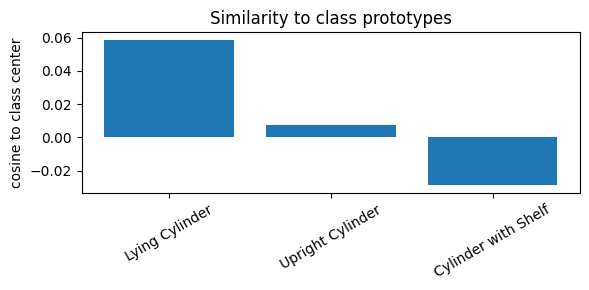

In [28]:
idx = 3  # 任选一个测试样本索引
_ = plot_sample_to_centers(
    model = model, 
    feat_vec=feats[idx], 
    class_names=list(ids2labels.values()), 
    topk=5
)

In [52]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def compute_class_centers(feats, labels):
    """按标签求特征均值，作为‘数据驱动类中心’（全部在CPU上算）"""
    X = torch.from_numpy(feats).float().cpu()
    y = torch.from_numpy(labels).long().cpu()
    C = int(y.max().item() + 1)
    centers = []
    for c in range(C):
        idx = (y == c).nonzero(as_tuple=False).squeeze(-1)
        mu = X[idx].mean(dim=0) if idx.numel() else torch.zeros(X.size(1))
        centers.append(mu)
    centers = torch.stack(centers, dim=0)         # [C, D]
    centers = F.normalize(centers, p=2, dim=1)
    return centers  # CPU tensor

@torch.no_grad()
def bar_sample_to_prototypes(
    feats,                 # numpy [N, D] (CPU)
    labels,                # numpy [N]
    idx,                   # 目标样本索引
    model,                 # 已加载模型
    use_classifier_weight=True,   # True: 用分类器权重；False: 用类中心
    class_names=None,             # 类名列表
    topk=5,
    annotate=True,
    show_prob_if_classifier=True  # 用 classifier 时，同时显示softmax概率
):
    """
    对样本 idx 画与各类原型的相似度柱状图，并高亮预测/真值。
    计算均在CPU执行，避免device报错。
    返回: dict(sim, order, pred_idx, true_idx, topk_idx, topk_vals, probs)
    """
    # ---------------- 1) 准备样本特征（CPU & 归一化） ----------------
    x = torch.from_numpy(feats[idx:idx+1]).float().cpu()   # [1, D]
    x = F.normalize(x, p=2, dim=1)

    true_idx = int(labels[idx])

    # ---------------- 2) 准备“原型” ----------------
    if use_classifier_weight:
        W = model.classifier.weight.detach().cpu().float()     # [C, D]
        protos = F.normalize(W, p=2, dim=1)                    # 用于cosine
        title_src = "classifier weights"
        # 预测类别（若有 bias 则加上）
        if hasattr(model.classifier, "bias") and model.classifier.bias is not None:
            b = model.classifier.bias.detach().cpu().float()   # [C]
            logits = (x @ W.t()).squeeze(0) + b                # [C]
        else:
            logits = (x @ W.t()).squeeze(0)                    # [C]
        pred_idx = int(torch.argmax(logits).item())
        # softmax 概率（仅在用 classifier 权重时可用）
        probs = torch.softmax(logits, dim=0).cpu().numpy()
    else:
        protos = compute_class_centers(feats, labels)          # [C, D] (CPU)
        title_src = "class centers"
        pred_idx = None
        probs = None

    # ---------------- 3) 与各类原型的余弦相似度 ----------------
    sim = (x @ protos.t()).squeeze(0).cpu().numpy()           # [C]
    order = np.argsort(-sim)                                  # 从大到小
    C = sim.shape[0]
    topk = int(min(topk, C))
    top_idx = order[:topk]
    top_vals = sim[top_idx]

    # ---------------- 4) 画图（高亮预测/真值 + 顶部标注） ----------------
    fig, ax = plt.subplots(figsize=(6.4, 3.6))

    # 颜色：默认一色；预测/真值分别用不同颜色
    base_color = "#4C78A8"
    pred_color = "#F58518"
    true_color = "#54A24B"
    colors = [base_color for _ in range(topk)]
    if pred_idx is not None:
        for i, cidx in enumerate(top_idx):
            if cidx == pred_idx:
                colors[i] = pred_color
    for i, cidx in enumerate(top_idx):
        if cidx == true_idx:
            # 若与预测重叠，则用更醒目的颜色（也可以画边框，这里直接覆盖）
            colors[i] = true_color

    bars = ax.bar(np.arange(topk), top_vals, color=colors, alpha=0.95)

    # x 轴标签
    if class_names:
        xt = [class_names[i] for i in top_idx]
    else:
        xt = [str(i) for i in top_idx]
    ax.set_xticks(np.arange(topk))
    ax.set_xticklabels(xt) #rotation=15, ha="cencter"

    ax.set_ylabel("cosine similarity")
    ax.set_title(f"Why this class?  (prototypes = {title_src})")

    # 给一点headroom防止数值贴顶
    ymin, ymax = min(0.0, top_vals.min()*1.3), max(0.0, top_vals.max()*1.1)
    if abs(ymax - ymin) < 1e-6:  # 退化保护
        ymax = ymin + 1.0
    ax.set_ylim(ymin, ymax + 0.08 * (ymax - ymin))

    # 顶部标注（负值放在柱子下方）
    if annotate:
        rng = ax.get_ylim()[1] - ax.get_ylim()[0]
        for rect, v in zip(bars, top_vals):
            xmid = rect.get_x() + rect.get_width()/2
            dy = 0.02 * rng
            va = "bottom" if v >= 0 else "top"
            ax.text(xmid, v + (dy if v >= 0 else -dy), f"{v:.2f}",
                    ha="center", va=va, fontsize=9)

    # 图例（仅在有预测时）
    if pred_idx is not None:
        handles = []
        # 只在图里确实出现过时才加图例项
        if any(c == pred_color for c in colors):
            handles.append(plt.Rectangle((0,0),1,1,color=pred_color,label="pred class"))
        if any(c == true_color for c in colors):
            handles.append(plt.Rectangle((0,0),1,1,color=true_color,label="true class"))
        if handles:
            ax.legend(handles=handles, frameon=False, loc="upper right")

    plt.tight_layout()
    plt.show()

    # ---------------- 5) 返回数据，方便记录/复用 ----------------
    out = {
        "sim": sim,                       # 全部类别的相似度（numpy [C]）
        "order": order,                   # 从大到小的排序（numpy [C]）
        "pred_idx": pred_idx,             # 预测类别（或 None）
        "true_idx": true_idx,             # 真值类别
        "topk_idx": top_idx,              # 图里展示的类别顺序
        "topk_vals": top_vals,            # 图里展示的相似度值
        "probs": probs                    # 若用 classifier 权重：softmax 概率 [C]；否则 None
    }
    return out

In [53]:
ids2labels

{0: 'Upright Cylinder', 1: 'Cylinder with Shelf', 2: 'Lying Cylinder'}

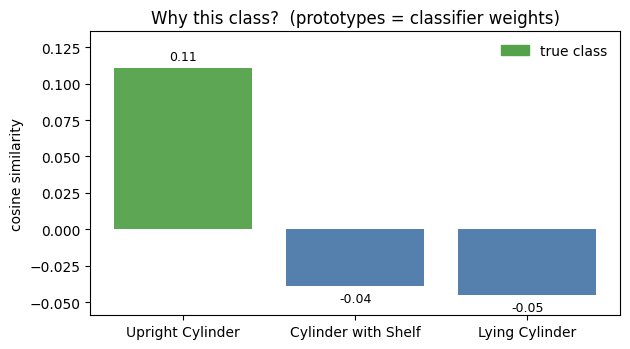

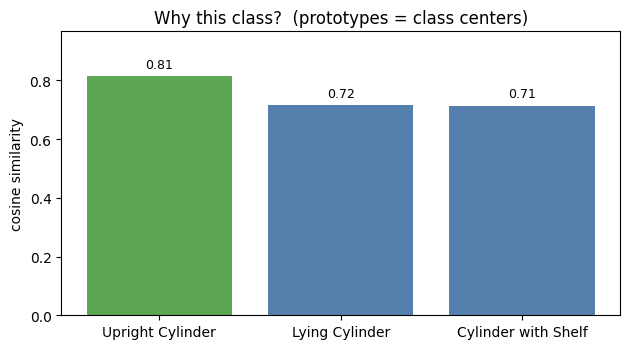

In [54]:
idx = 10  # 任意一个测试样本索引

# (W原型): 用的是分类器的权重向量当“类原型”。它代表决策边界的法向量/拉向该类的方向（受损失函数、正则、margin/scaling 影响），更贴近“模型想要你去的方向”
# 从模型的视角回答：“为什么被判成这个类（从模型视角）？
outC = bar_sample_to_prototypes(feats, labels, idx, model, use_classifier_weight=True,  class_names=ids2labels)
# (Center原型): 用的是数据驱动的类中心（由当前特征的类别均值算的）。它反映数据实际分布与类内聚合情况，更贴近“数据真的长什么样”。
# 从数据的视角回答：这个样本像哪个类的平均样子（从数据视角）？
outW = bar_sample_to_prototypes(feats, labels, idx, model, use_classifier_weight=False, class_names=ids2labels)

## 3.3 支持样本检索（Nearest Examples）
\*注：对样本分析的作用不大，所以最后的分析不用这个部分的内容。

In [66]:
# import numpy as np
# import matplotlib.pyplot as plt
# import torch
# import torch.nn.functional as F

# def knn_indices(feats, q_idx, k=8):
#     X = torch.from_numpy(feats).float()
#     X = F.normalize(X, p=2, dim=1)
#     q = X[q_idx:q_idx+1]               # [1,D]
#     sim = (q @ X.t()).squeeze(0)       # [N]
#     order = torch.argsort(-sim).cpu().numpy()
#     # 跳过自己
#     order = order[order!=q_idx]
#     return order[:k], sim.cpu().numpy()

# def show_retrieval_grid(imgs_tensor, indices, cols=8, title="Nearest neighbors (crop)"):
#     """imgs_tensor: [N,3,224,224]（crop 或 global 均可）"""
#     imgs = imgs_tensor[indices].clamp(0,1).permute(0,2,3,1).numpy()
#     rows = int(np.ceil(len(indices)/cols))
#     plt.figure(figsize=(cols*1.7, rows*1.7))
#     for i, im in enumerate(imgs):
#         plt.subplot(rows, cols, i+1); plt.imshow(im); plt.axis('off')
#     plt.suptitle(title); plt.tight_layout(); plt.show()

In [65]:
# topK, sim = knn_indices(feats, idx, k=6)
# show_retrieval_grid(imgs_crop,   topK, cols=6, title="Nearest neighbors on CROP features")
# # 也可以看 global：

In [62]:
# show_retrieval_grid(imgs_global, topK, cols=6, title="Nearest neighbors on GLOBAL-aligned features")